# ติดตั้ง Python Socket Library
รันคำสั่ง pip install socket บน terminal

# Check ว่าติดตั้งแล้วหรือยัง
pip list บน Terminal

## ฟังก์ชันและ Method API ซ็อกเก็ตหลักในโมดูลนี้ได้แก่
- socket()
- .bind()
- .listen()
- .accept()
- .connect()
- .connect_ex()
- .send()
- .recv()
- .close()

### Transmission Control Protocol (TCP)
- Packet ที่สูญหายในเครือข่ายจะถูกตรวจจับและส่งซ้ำโดยผู้ส่ง
- มีการส่งข้อมูลตามลำดับ แอปพลิเคชันของคุณจะอ่านข้อมูลตามลำดับที่ผู้ส่งเขียนไว้

เราจะใช้ object `socket.socket()`
และกำหนด Type ให้เป็น `socket.SOCK_STREAM`

### User Datagram Protocol (UDP)
ถ้าเป็น UDP จะใช้ Type เป็น `socket.SOCK_DGRAM` ถ้าใช้วิธีนี้ข้อมูลที่ผู้รับอ่านอาจไม่เรียงลำดับจากข้อมูลที่ผู้ส่งเขียน

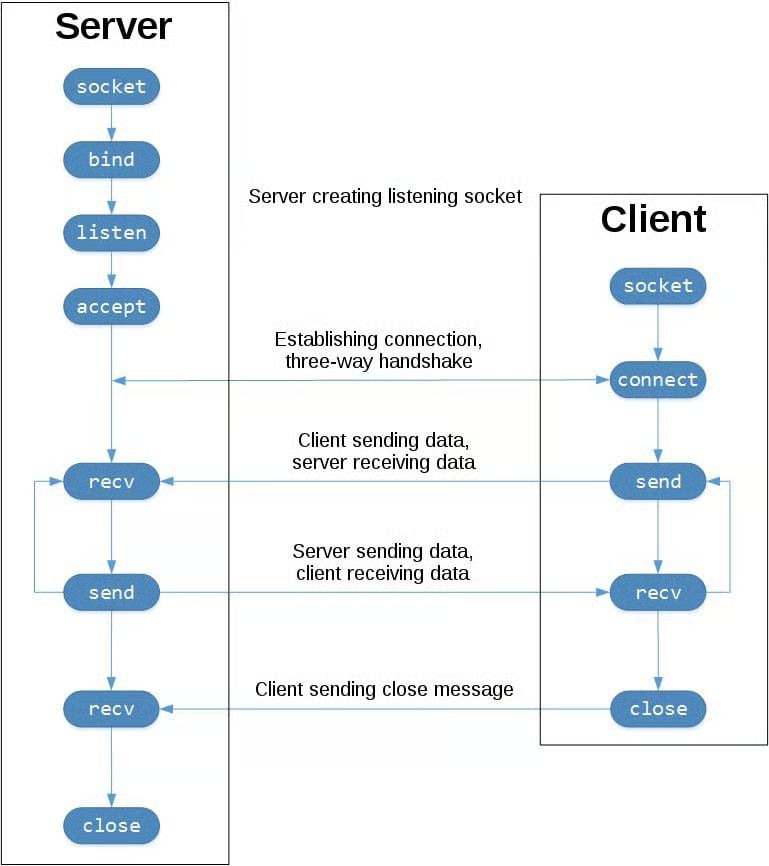

### ฝั่งซ้ายสุด
เรียกใช้ API ที่ Server ใช้เพื่อการตั้งค่า Socket สำหรับ "รอรับการเชื่อมต่อ"
- socket()
- .bind()
- .listen()
- .accept()

โดย listening socket จะรอให้มีการเชื่อมต่อจาก Client เข้ามา แล้ว Server ก็จะเรียก .accept() เพื่อยอมรับหรือยืนยันการเชื่อมต่อ

In [ ]:
import socket

HOST = "192.168.5.1"
PORT = 54600

with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.bind((HOST, PORT))
    s.listen()
    conn, addr = s.accept()
    with conn:
        print(f"Connected by {addr}")
        while True:
            data = conn.recv(1024)
            if not data:
                break
            conn.sendall(data)

### Argument ที่ส่งผ่านไปยังฟังก์ชัน Socket()
เป็นค่าคงที่ที่ใช้ระบุตระกูลที่อยู่ โดย AF_INET คือตระกูลที่อยู่ IPv4 

1. ส่วน SOCK_STREAM คือประเภท Socket สำหรับ TCP ซึ่งเป็นโปรโตคอลที่ใช้ในการส่งข้อความในเครือข่าย

    ``` Python
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        pass  # Use the socket object without calling s.close().    
    ```

2. ส่วน `.bind()` ใช้เพื่อเชื่อมโยง Socket กับอินเทอร์เฟซผ่านเครือข่ายและหมายเลขพอร์ตที่เฉพาะเจาะจง

    ซึ่งเราใช้ Socket แบบ `socket.AF_INET(IPv4)` มันคาดหวัง tuple 2 ตัว เราจึงส่งค่าแบบนี้ 
    ``` Python
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind((HOST, PORT))
    ```

3. Method ส่วน `.listen()` ทำให้เซิร์ฟเวอร์สามารถรับการเชื่อมต่อได้ โดยทำให้ Server เป็น Socket ที่รอรับการเชื่อมต่อ

    ```
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind((HOST, PORT))
        s.listen()
        conn, addr = s.accept()
        # ...
    ```

    `.listen()` จะมี backlog parameter หนึ่งตัว ซึ่งจะระบุจำนวนการเชื่อมต่อที่ไม่ได้รับอนุญาตก่อนจะปฏิเสธการเชื่อมต่อใหม่

4. Method `.accept()` จะหยุดการทำงานและรอการเชื่อมต่อขาเข้า เมื่อ Client เชื่อมต่อ ระบบจะส่งคืน Object ซ็อกเก็ตใหม่ที่แสดงถึงการเชื่อมต่อและทูเปิลที่เก็บที่อยู่ของ Client 

    Tuple จะมี (host, port) ค่าสำหรับ IPv4 
    แต่ถ้าเป็น IPv6 จะมี (host, port, flowinfo, scopeid)

    พอ Server accept ก็จะได้ object มา 2 ตัว นั่นคือ conn และ addr

5. หลังจาก `accept()` จัดเตรียม Object Socket Client แล้วก็จะใช้ while True infinity loop เพื่อวนซ้ำ conn 

    ทำไมต้องใช้ while loop ?

    เพราะว่า Server ไม่รู้ล่วงหน้าว่าลูกค้าคนนี้จะส่งข้อความมาทั้งหมดกี่ข้อความ จึงต้องเปิดลูปแสตนด์บายรอรับข้อความไปเรื่อย ๆ

    ``` Python
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            s.bind((HOST, PORT))
            s.listen()
            conn, addr = s.accept()
            with conn:
                print(f"Connected by {addr}")
                while True:
                    data = conn.recv(1024)
                    if not data:
                        break
                    conn.sendall(data)
    ```

    - การทำงานแบบ Blocking: เมื่อโปรแกรมรันมาถึงบรรทัด `data = conn.recv(1024)` โปรแกรมจะหยุดนิ่งและรออยู่ที่บรรทัดนั้น จนกว่า Client จะส่งข้อมูลเข้ามา

    - การส่งกลับ `conn.sendall()` เมื่อ Client ส่งข้อมูลมา โปรแกรมจะออกจากการบล็อกแล้วเอาข้อมูลนั้นมาประมวลผล (ในทีนี้คือการส่งข้อมูลเดียวกันกลับไป หรือที่เรียกว่า Echo Server) โดยใช้ `conn.sendall()` จากนั้นมันก็จะวนลูปไปที่บรรทัด `conn.recv()` เพื่อรอค่าใหม่ต่อไป

#### จะรู้ได้ยังไงว่า Client ปิดการเชื่อมต่อ ??
ฝั่ง Server ที่เปิดรอรับอยู่ที่ `conn.recv()` จะได้รับข้อมูลตอบกลับมาเป็น Empty Bytes หรือ `b''`
ภายในโค้ดของเราก็เลยมีการเช็คเงื่อนไขนั้น

#### Backlog คืออะไร ???
เมื่อ Server เปิดการใช้งานด้วย `.listen()` มันจะเริ่มรอรับการเชื่อมต่อจากไคลเอนต์ แต่ในโลกความเป็นจริง Server อาจจะได้รับคำขอการเชื่อมต่อเข้ามาพร้อมกันหลายเครื่องในเสี้ยววินาที แล้วในขณะที่ Server กำลังประมวลผลการเชื่อมต่อแรกอยู่ (ยังไม่ได้เรียก .accept()) การเชื่อมต่ออื่น ๆ ที่พยายามเข้ามาจะถูกส่งไปต่อคิวรอไว้ก่อน

`Backlog` ก็คือความยาวสูงสุดของคิวที่ยอมให้มีเครื่องมาต่อรอเชื่อมต่อนั่นเอง

### ฝั่งขวาสุด (Client)
เรียกใช้ API ที่ Client ใช้เพื่อ "เชื่อมต่อ" ไปยัง Server ที่เปิดรออยู่
- socket()
- .connect()
- .sendall()
- .recv()

ต่างจาก Server ตรงที่ Client ไม่ต้อง `.bind()` หรือ `.listen()` เพราะ Client เป็นฝ่าย "เริ่มเชื่อมต่อออกไปหา" ไม่ใช่ฝ่ายรอรับ

In [ ]:
import socket

HOST = "192.168.5.1"
PORT = 54600

with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.connect((HOST, PORT))
    s.sendall(b"Hello, world")
    data = s.recv(1024)

print(f"Received {data!r}")

### Argument ที่ส่งผ่านไปยัง Client Socket

1. `socket.socket(socket.AF_INET, socket.SOCK_STREAM)` เหมือนกับฝั่ง Server เป๊ะ ๆ เพราะทั้งสองฝั่งต้องคุยกันด้วยโปรโตคอลเดียวกัน (TCP)

2. `.connect((HOST, PORT))` คือจุดที่ต่างจาก Server ชัดเจนที่สุด — Client ไม่ `.bind()` ไม่ `.listen()` ไม่ `.accept()` แต่ใช้ `.connect()` เพื่อ "วิ่งออกไปขอเชื่อมต่อ" กับ Server ที่ระบุ (HOST, PORT) ไว้โดยตรง

    ระบบปฏิบัติการจะเลือก Port ฝั่ง Client ให้อัตโนมัติ (Ephemeral Port) เราจึงไม่ต้อง `.bind()` เอง

3. `.sendall(b"Hello, world")` ใช้ส่งข้อมูล (ต้องเป็น bytes) ไปให้ Server ต่างจาก `.send()` ตรงที่ `.sendall()` จะพยายามส่งข้อมูล *ทั้งหมด* ให้ครบก่อนจะ return ส่วน `.send()` อาจส่งได้ไม่ครบในครั้งเดียวแล้วคืนจำนวน byte ที่ส่งไปจริง ทำให้ต้องเขียน loop เองถ้าจะใช้ `.send()`

4. `data = s.recv(1024)` รอรับข้อมูลตอบกลับจาก Server แบบ Blocking เหมือนฝั่ง Server เลย เมื่อไหร่ Server เรียก `conn.sendall(data)` กลับมา บรรทัดนี้ก็จะได้ค่าและทำงานต่อ

#### ลองรันดู
1. รัน cell ของ Server ก่อน (ในเครื่อง/เทอร์มินัลเดียวกันหรือคนละเครื่องก็ได้ ถ้า `HOST` เข้าถึงกันได้) — มันจะไป Block รออยู่ที่ `.accept()`
2. แล้วค่อยรัน cell ของ Client — Client จะเชื่อมต่อ ส่ง `b"Hello, world"` แล้วรอรับ Echo กลับมา
3. เมื่อ Client จบ `with` block ไป Socket จะถูกปิดอัตโนมัติ ฝั่ง Server จะได้ `b''` จาก `conn.recv()` แล้วหลุดออกจาก while loop เอง

หมายเหตุ: ถ้ารันทั้งสอง cell ในโน้ตบุ๊กเดียวกัน (single-threaded) Server cell จะ Block ไม่ให้ cell ถัดไปรันจนกว่าจะ `.accept()` เสร็จ — สำหรับทดสอบจริงแนะนำให้แยกรัน Server เป็นสคริปต์ `.py` ในเทอร์มินัลแยกต่างหาก แล้วค่อยรัน Client cell ในโน้ตบุ๊ก

### หมายเหตุหากลองรันบนคอมพิวเตอร์เครื่องเดียวกันให้ใช้ IP
HOST = 127.0.0.1

วิธีการรัน
1. เข้าไปที่ Folder tutorials/Python_socket
    - cd tutorials
    - cd Python_socket
2. ทำการรันโดยใช้คำสั่ง python แล้วตามด้วยชื่อไฟล์
    - python server.py
    - python client.py